**Data Science and Machine Learning course - Batch-115**

**DSML-B115-Project-Submission**

**Submission Date: 08/03/2026**

**General Instructions for Project Submission**
- Please download all the given file(s) for this Project
- After completing the project work, **Please zip all the files** - Python code with results, screenshots, text file, etc. Any file please zip all, and upload as a single file.
- That zip file's name, keep it based on this sample name "**dsml115_Project_<your_firstname>_<your_initial>.zip**"
- Upload File option will be present after clicking the "Attempt Now" button in the Assignments page
- For clarity about the Assignment, **refer the class video recordings** or ask questions during the Doubt Clearing Session

--------------------------------

### **Batch-115 Final Project Presentation**
- **Dataset and goals:** End-to-end ML project of your choice from the domains of Healthcare, Finance, Education, Manufacturing, or others
    - **Note:** Go through all concepts from C1 to C17
- **Total time for each**: 15 minutes (10 minutes presentation + 5 minutes Q/A)
    - Presentation content file: **Jupyter Notebook** file (OR) **PPT** file
        - If only **PPT** - You need to take **screenshots of your code** and explain it clearly in total time of 10 minutes
- **10 minutes** - Screen share and present your project
    - **Note:**
        - The core goal of the presentation is NOT TO GO THROUGH Entire project
        - The core goal of the presentation is **TO SUMMARIZE your process and output** of your ML project
- **5 minutes** - Q/A will be at the end of the presentation
    - Eg: About the dataset, data preprocessing techniques, ml models, etc.

### step-1 **goal setting for the project**

In [ ]:
"""
GOAL
ML Algorithms :
supervised learning : regression, classification -> Target : predict a gamer’s addiction risk level based on gaming habits, sleep and social behavior?
unsupervised learning : clustering, dimensionality reduction -> Target : identify patterns or groupings among gamers based on their habits, sleep, mood, physical health, and social behavior to understand different addiction risk profiles.
Hyperparameter Tuning : Grid Search, Random Search -> Target : optimize the performance of the chosen machine learning model by finding the best hyperparameters for predicting addiction risk levels.
"""



'\nGOAL\nML Algorithms :\nsupervised learning : regression, classification -> Target : predict a gamer’s addiction risk level based on gaming habits, sleep and social behavior?\nunsupervised learning : clustering, dimensionality reduction -> Target : identify patterns or groupings among gamers based on their habits, sleep, mood, physical health, and social behavior to understand different addiction risk profiles.\n'

### step-2 **collect the dataset**

In [1]:
import pandas as pd
import numpy as np
data = pd.read_csv('Gaming and Mental Health.csv')
df = data.copy(deep=False)
df_1 = df.copy(deep=False)#For unsupervised learning
df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


### step-3 **prepare the dataset**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        754 non-null    float64
 12  work_pr

In [5]:
#drop columns that are not relevant to the analysis or have too many missing values
df = df.drop(columns=["record_id","game_genre","grades_gpa","work_productivity_score","gaming_platform","primary_game","sleep_quality","exercise_hours_weekly","monthly_game_spending_usd","sleep_disruption_frequency","academic_work_performance","mood_state","mood_swing_frequency","withdrawal_symptoms","loss_of_other_interests","continued_despite_problems"],errors='ignore')
df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               1000 non-null   int64  
 1   gender                            1000 non-null   object 
 2   daily_gaming_hours                1000 non-null   float64
 3   sleep_hours                       1000 non-null   float64
 4   eye_strain                        1000 non-null   bool   
 5   back_neck_pain                    1000 non-null   bool   
 6   weight_change_kg                  1000 non-null   float64
 7   social_isolation_score            1000 non-null   int64  
 8   face_to_face_social_hours_weekly  1000 non-null   float64
 9   years_gaming                      1000 non-null   int64  
 10  gaming_addiction_risk_level       1000 non-null   object 
dtypes: bool(2), float64(4), int64(3), object(2)
memory usage: 72.4+ KB


In [6]:
# Convert the relevant columns to numeric types
df["gender"] = df["gender"].replace({"Male":0,"Female":1,"Other":2})
df["gaming_addiction_risk_level"] = df["gaming_addiction_risk_level"].replace({"Low":0,"Moderate":1,"High":2,"Severe":3})
print(df["gender"].value_counts())

gender
0    647
1    331
2     22
Name: count, dtype: int64


C:\Users\91638\AppData\Local\Temp\ipykernel_17160\3556474345.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["gender"] = df["gender"].replace({"Male":0,"Female":1,"Other":2})
C:\Users\91638\AppData\Local\Temp\ipykernel_17160\3556474345.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["gaming_addiction_risk_level"] = df["gaming_addiction_risk_level"].replace({"Low":0,"Moderate":1,"High":2,"Severe":3})


In [7]:
## Convert the relevant columns to numeric types
df["eye_strain"] = df["eye_strain"].astype("int64")
df["back_neck_pain"] = df["back_neck_pain"].astype("int64")
print(df["eye_strain"].value_counts())
print(df["back_neck_pain"].value_counts())

eye_strain
0    503
1    497
Name: count, dtype: int64
back_neck_pain
0    652
1    348
Name: count, dtype: int64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               1000 non-null   int64  
 1   gender                            1000 non-null   int64  
 2   daily_gaming_hours                1000 non-null   float64
 3   sleep_hours                       1000 non-null   float64
 4   eye_strain                        1000 non-null   int64  
 5   back_neck_pain                    1000 non-null   int64  
 6   weight_change_kg                  1000 non-null   float64
 7   social_isolation_score            1000 non-null   int64  
 8   face_to_face_social_hours_weekly  1000 non-null   float64
 9   years_gaming                      1000 non-null   int64  
 10  gaming_addiction_risk_level       1000 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 86.1 KB


### step-4 **feauture engineering**

<Axes: >

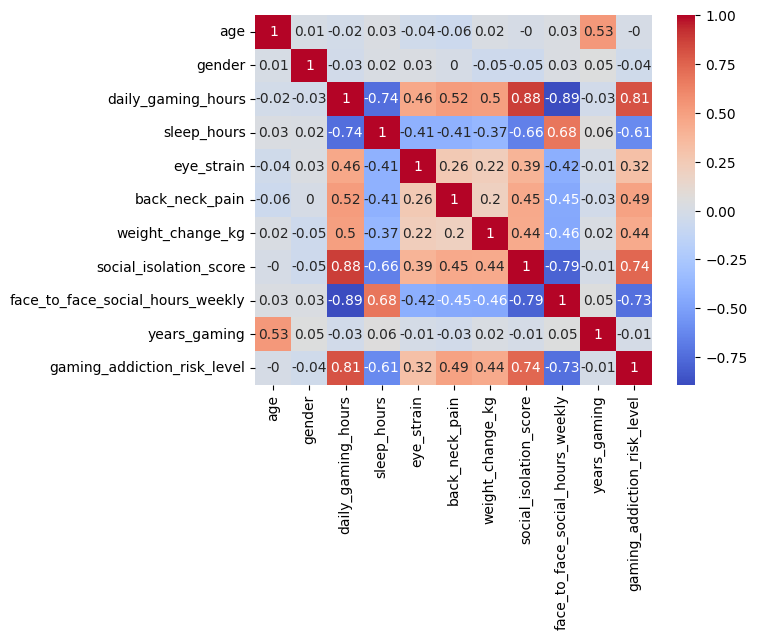

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
correlation = df.corr()
sns.heatmap(correlation.round(2), annot=True, cmap='coolwarm')

In [9]:
df["gaming_addiction_risk_level"].value_counts()

gaming_addiction_risk_level
0    514
1    190
2    154
3    142
Name: count, dtype: int64

In [11]:
df.head(2)

,age,gender,daily_gaming_hours,sleep_hours,eye_strain,back_neck_pain,weight_change_kg,social_isolation_score,face_to_face_social_hours_weekly,years_gaming,gaming_addiction_risk_level
0,17,0,11.1,3.7,1,0,6.8,7,1.3,3,3
1,21,0,3.0,7.2,0,0,0.4,2,10.7,1,0


### step-5 **split the dataset for "training" and "testing"**

In [3]:
from sklearn.model_selection import train_test_split
#splitting the dataset for training and testing
ml_data_split_output = train_test_split(df,test_size=0.3)
train_data,test_data = ml_data_split_output[0],ml_data_split_output[1]
print(len(train_data))
print(len(test_data))


700
300


### step-6 **apply "ML alogorithm" to "training data" to create a ML "model"**

In [11]:
#importing the necessary machine learning classification algorithms
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
#splitting the dataset into features and target variable
x_train = train_data.drop(columns=["gaming_addiction_risk_level"])
y_train = train_data["gaming_addiction_risk_level"]
x_test = test_data.drop(columns=["gaming_addiction_risk_level"])
#scaling the features for distance based models to make better performance of models
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [12]:
x_test_scaled

array([[ 1.8037055 , -0.72728998,  0.54027451, ...,  0.54053746,
         0.02164417, -0.21045919],
       [-0.62016444, -0.72728998,  1.47305866, ...,  1.01115465,
        -0.53362501, -0.21045919],
       [-0.86255143,  1.23835861, -1.46348405, ..., -1.3419313 ,
         0.99997557,  0.04982603],
       ...,
       [-1.34732542,  1.23835861, -0.32341453, ...,  0.06992027,
         0.55047195, -0.73102961],
       [-0.37777744,  1.23835861, -0.28886697, ...,  0.54053746,
        -0.29565251, -0.99131482],
       [ 0.34938354,  1.23835861, -0.94527063, ..., -0.40069692,
         1.68745169,  1.6115373 ]], shape=(300, 10))

In [13]:
#creating and training the machine learning models
lr_model = LinearRegression().fit(x_train_scaled,y_train)
dt_model = DecisionTreeClassifier(random_state=123).fit(x_train,y_train)
svm_model = SVC(random_state=42).fit(x_train_scaled,y_train)

### step-7 **evaluate the model using the testing data**

In [14]:
#testing the models and evaluating their performance
lr_predictions = lr_model.predict(x_test_scaled)
dt_predictions = dt_model.predict(x_test)
svm_predictions = svm_model.predict(x_test_scaled)

In [19]:
print(pd.Series(dt_predictions).value_counts())

0    158
1     49
2     49
3     44
Name: count, dtype: int64


In [68]:
#true labels for the test set
true_labels = test_data["gaming_addiction_risk_level"]
true_labels.value_counts()

gaming_addiction_risk_level
0    155
1     57
2     51
3     37
Name: count, dtype: int64

### step-8 **prediction result summary**

In [69]:
#evaluating the performance of the models using appropriate metrics
#model 1 : Linear Regression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,accuracy_score,precision_score,recall_score,f1_score
print("Linear Regression Performance:")
print("R2 Score : ",r2_score(true_labels,lr_predictions))
print("Mean Absolute Error : ",mean_absolute_error(true_labels,lr_predictions))
print("Mean Squared Error : ",mean_squared_error(true_labels,lr_predictions))

Linear Regression Performance:
R2 Score :  0.6654917739023418
Mean Absolute Error :  0.5018654700593023
Mean Squared Error :  0.39137462453426025


In [70]:
#model 2 : Decision Tree Classifier
print("Decision Tree Classifier Performance:")
print("Accuracy Score : ",accuracy_score(true_labels,dt_predictions))
print("Precision Score : ",precision_score(true_labels,dt_predictions,average='weighted'))
print("Recall Score : ",recall_score(true_labels,dt_predictions,average='weighted'))
print("F1 Score : ",f1_score(true_labels,dt_predictions,average='weighted'))

Decision Tree Classifier Performance:
Accuracy Score :  0.6666666666666666
Precision Score :  0.670671674503349
Recall Score :  0.6666666666666666
F1 Score :  0.6682037923709537


In [71]:
#model 3 : Support Vector classifier
print("Support Vector Classifier Performance:")
print("Accuracy Score : ",accuracy_score(true_labels,svm_predictions))
print("Precision Score : ",precision_score(true_labels,svm_predictions,average='weighted'))
print("Recall Score : ",recall_score(true_labels,svm_predictions,average='weighted'))
print("F1 Score : ",f1_score(true_labels,svm_predictions,average='weighted'))

Support Vector Classifier Performance:
Accuracy Score :  0.6933333333333334
Precision Score :  0.6972405349640788
Recall Score :  0.6933333333333334
F1 Score :  0.6825249484634852


## Create an unsupervised ML model 

### **GOAL - Clustering and Evaluation**

#### The Elbow Method
- Refer: https://www.kdnuggets.com/2023/04/exploring-unsupervised-learning-metrics.html

#### KMeans Clustering
- Refer: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

#### Evaluation Metrics
- Refer: https://www.kdnuggets.com/2023/04/exploring-unsupervised-learning-metrics.html

In [ ]:
"""
The first 5 steps from supervised learning model development is same as in unsupervised learning.
so we will skip those steps and directly jump to several steps that are specific to unsupervised learning.
"""

### **step-6 apply ML algorithm for unsupervised learning**

In [73]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
# Need to know the best possible cluster number --> Through Elbow method

In [72]:
df_1 = df_1.drop(columns=["record_id","age","game_genre","primary_game","weight_change_kg","years_gaming ","gaming_platform","sleep_quality","sleep_disruption_frequency","academic_work_performance","gender","eye_strain","back_neck_pain","gaming_addiction_risk_level","grades_gpa","work_productivity_score","mood_state","face_to_face_social_hours_weekly","withdrawal_symptoms","loss_of_other_interests","continued_despite_problems"],errors='ignore')
#change the mood_swing_frequency column to numeric values for clustering
df_1["mood_swing_frequency"] = df_1["mood_swing_frequency"].replace({"Never":0,"Rarely":1,"Sometimes":2,"Often":3,"Daily":4})
df_1["mood_swing_frequency"].value_counts()

C:\Users\91638\AppData\Local\Temp\ipykernel_12776\112463837.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_1["mood_swing_frequency"] = df_1["mood_swing_frequency"].replace({"Never":0,"Rarely":1,"Sometimes":2,"Often":3,"Daily":4})


mood_swing_frequency
2    214
4    206
1    202
0    190
3    188
Name: count, dtype: int64

Elbow Method

[12991351.847047098, 2765841.7669543503, 1248716.6105940677, 681177.9005977012, 475171.0419478094, 304586.6873338462, 232391.98613271353, 194065.12736598295, 160956.9049558983, 140722.64753510468]


Text(0.5, 1.0, 'Elbow Method for Optimal Clusters')

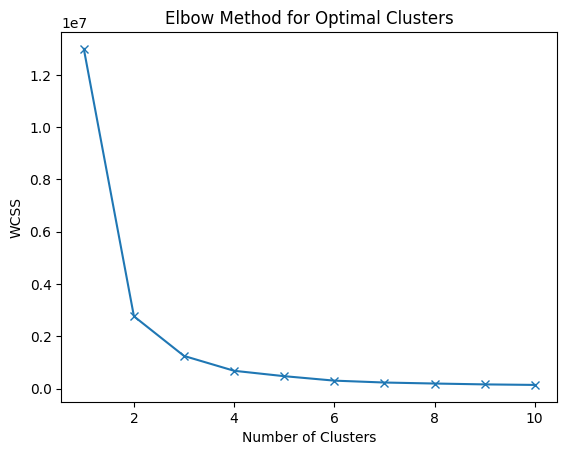

In [74]:
WCSS_list = []
for i in range(1,11):
    cluster_model = KMeans(n_clusters=i,random_state=42)
    cluster_model.fit(df_1)
    WCSS_list.append(cluster_model.inertia_)
print(WCSS_list)

import matplotlib.pyplot as plt
plt.plot(range(1,11),WCSS_list,marker='x')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal Clusters")

**From above experiment of Elbow Method, the best "number of clusters" to consider is 2**

<Axes: >

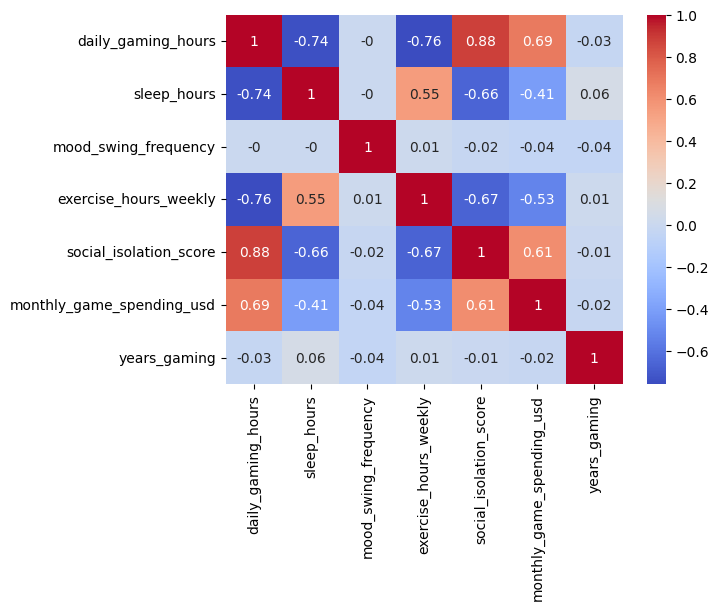

In [25]:
sns.heatmap(df_1.corr().round(2), annot=True, cmap='coolwarm')

In [75]:
cluster_model_1 = KMeans(n_clusters=2,random_state=42)
cluster_model_2 = AgglomerativeClustering(n_clusters=2)
cluster_model_1.fit(df_1)
cluster_model_2.fit(df_1)

,n_clusters,2
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [76]:
cluster_model_1.labels_

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,

In [77]:
cluster_model_2.labels_

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,

In [21]:
print(pd.Series(cluster_model_1.labels_).value_counts())
print(pd.Series(cluster_model_2.labels_).value_counts())

0    864
1    136
Name: count, dtype: int64
0    897
1    103
Name: count, dtype: int64


In [22]:
# Analyze the characteristics of each cluster
df_0_labels = df_1[cluster_model_1.labels_==0] #864 rows
df_1_labels = df_1[cluster_model_1.labels_==1] # 136 rows
print(len(df_0_labels.value_counts()))
print(len(df_1_labels.value_counts()))

864
136


In [23]:
cluster_model_2_labels_0 = df_1[cluster_model_2.labels_==0] #897 rows
cluster_model_2_labels_1 = df_1[cluster_model_2.labels_==1] #103 rows
print(len(cluster_model_2_labels_0.value_counts()))
print(len(cluster_model_2_labels_1.value_counts()))

897
103


In [24]:
cluster_model_2_labels_0.columns

Index(['daily_gaming_hours', 'sleep_hours', 'mood_swing_frequency',
       'exercise_hours_weekly', 'social_isolation_score',
       'monthly_game_spending_usd', 'years_gaming'],
      dtype='object')

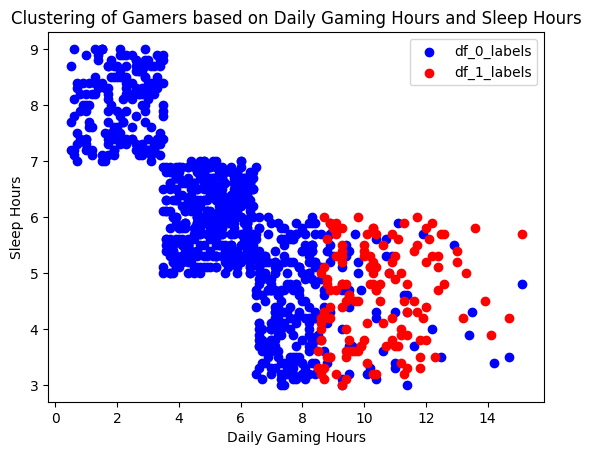

In [25]:
plt.scatter(df_0_labels["daily_gaming_hours"],df_0_labels["sleep_hours"],c="blue")
plt.scatter(df_1_labels["daily_gaming_hours"],df_1_labels["sleep_hours"],c="red")
plt.xlabel("Daily Gaming Hours")
plt.ylabel("Sleep Hours")
plt.legend(["df_0_labels","df_1_labels"])
plt.title("Clustering of Gamers based on Daily Gaming Hours and Sleep Hours")
plt.show()

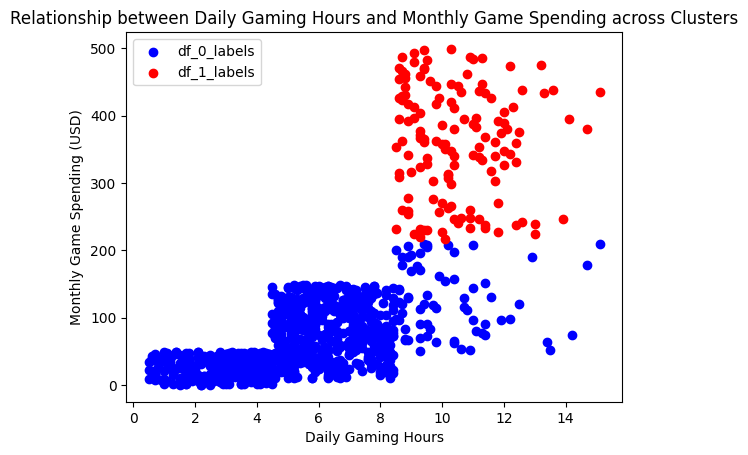

In [71]:
plt.scatter(df_0_labels["daily_gaming_hours"],df_0_labels["monthly_game_spending_usd"],color="blue")
plt.scatter(df_1_labels["daily_gaming_hours"],df_1_labels["monthly_game_spending_usd"],color="red")
plt.xlabel("Daily Gaming Hours")
plt.ylabel("Monthly Game Spending (USD)")
plt.title("Relationship between Daily Gaming Hours and Monthly Game Spending across Clusters")
plt.legend(["df_0_labels","df_1_labels"])
plt.show()

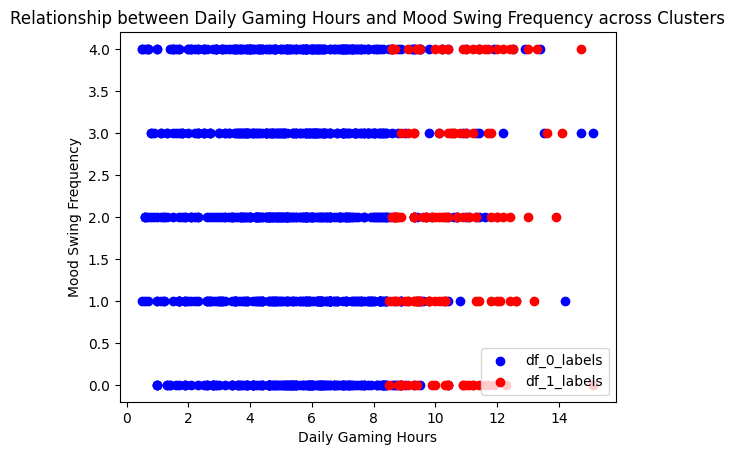

In [66]:
plt.scatter(df_0_labels["daily_gaming_hours"],df_0_labels["mood_swing_frequency"],c="blue")
plt.scatter(df_1_labels["daily_gaming_hours"],df_1_labels["mood_swing_frequency"],c="red")
plt.xlabel("Daily Gaming Hours")
plt.ylabel("Mood Swing Frequency")
plt.title("Relationship between Daily Gaming Hours and Mood Swing Frequency across Clusters")
plt.legend(["df_0_labels","df_1_labels"])
plt.show()

Text(0.5, 1.0, 'Clusters of Users Based on Gaming and Sleep Patterns')

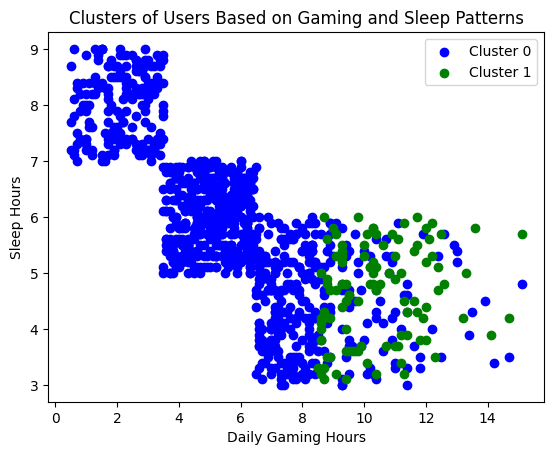

In [54]:
plt.scatter(cluster_model_2_labels_0["daily_gaming_hours"],cluster_model_2_labels_0["sleep_hours"],c="blue")
plt.scatter(cluster_model_2_labels_1["daily_gaming_hours"],cluster_model_2_labels_1["sleep_hours"],c="green")
plt.xlabel("Daily Gaming Hours")
plt.ylabel("Sleep Hours")
plt.legend(["Cluster 0","Cluster 1"])
plt.title("Clusters of Users Based on Gaming and Sleep Patterns")

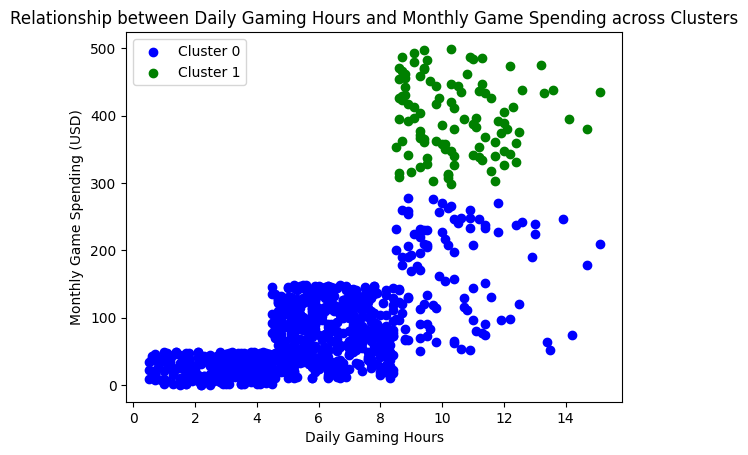

In [67]:
plt.scatter(cluster_model_2_labels_0["daily_gaming_hours"],cluster_model_2_labels_0["monthly_game_spending_usd"],c="blue")
plt.scatter(cluster_model_2_labels_1["daily_gaming_hours"],cluster_model_2_labels_1["monthly_game_spending_usd"],c="green")
plt.xlabel("Daily Gaming Hours")
plt.ylabel("Monthly Game Spending (USD)")
plt.title("Relationship between Daily Gaming Hours and Monthly Game Spending across Clusters")
plt.legend(["Cluster 0","Cluster 1"])
plt.show()

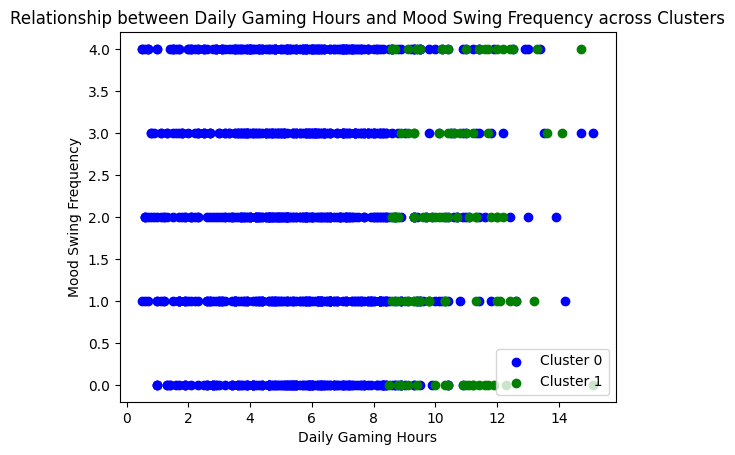

In [68]:
plt.scatter(cluster_model_2_labels_0["daily_gaming_hours"],cluster_model_2_labels_0["mood_swing_frequency"],c="blue")
plt.scatter(cluster_model_2_labels_1["daily_gaming_hours"],cluster_model_2_labels_1["mood_swing_frequency"],c="green")
plt.xlabel("Daily Gaming Hours")
plt.ylabel("Mood Swing Frequency")
plt.title("Relationship between Daily Gaming Hours and Mood Swing Frequency across Clusters")
plt.legend(["Cluster 0","Cluster 1"])
plt.show()

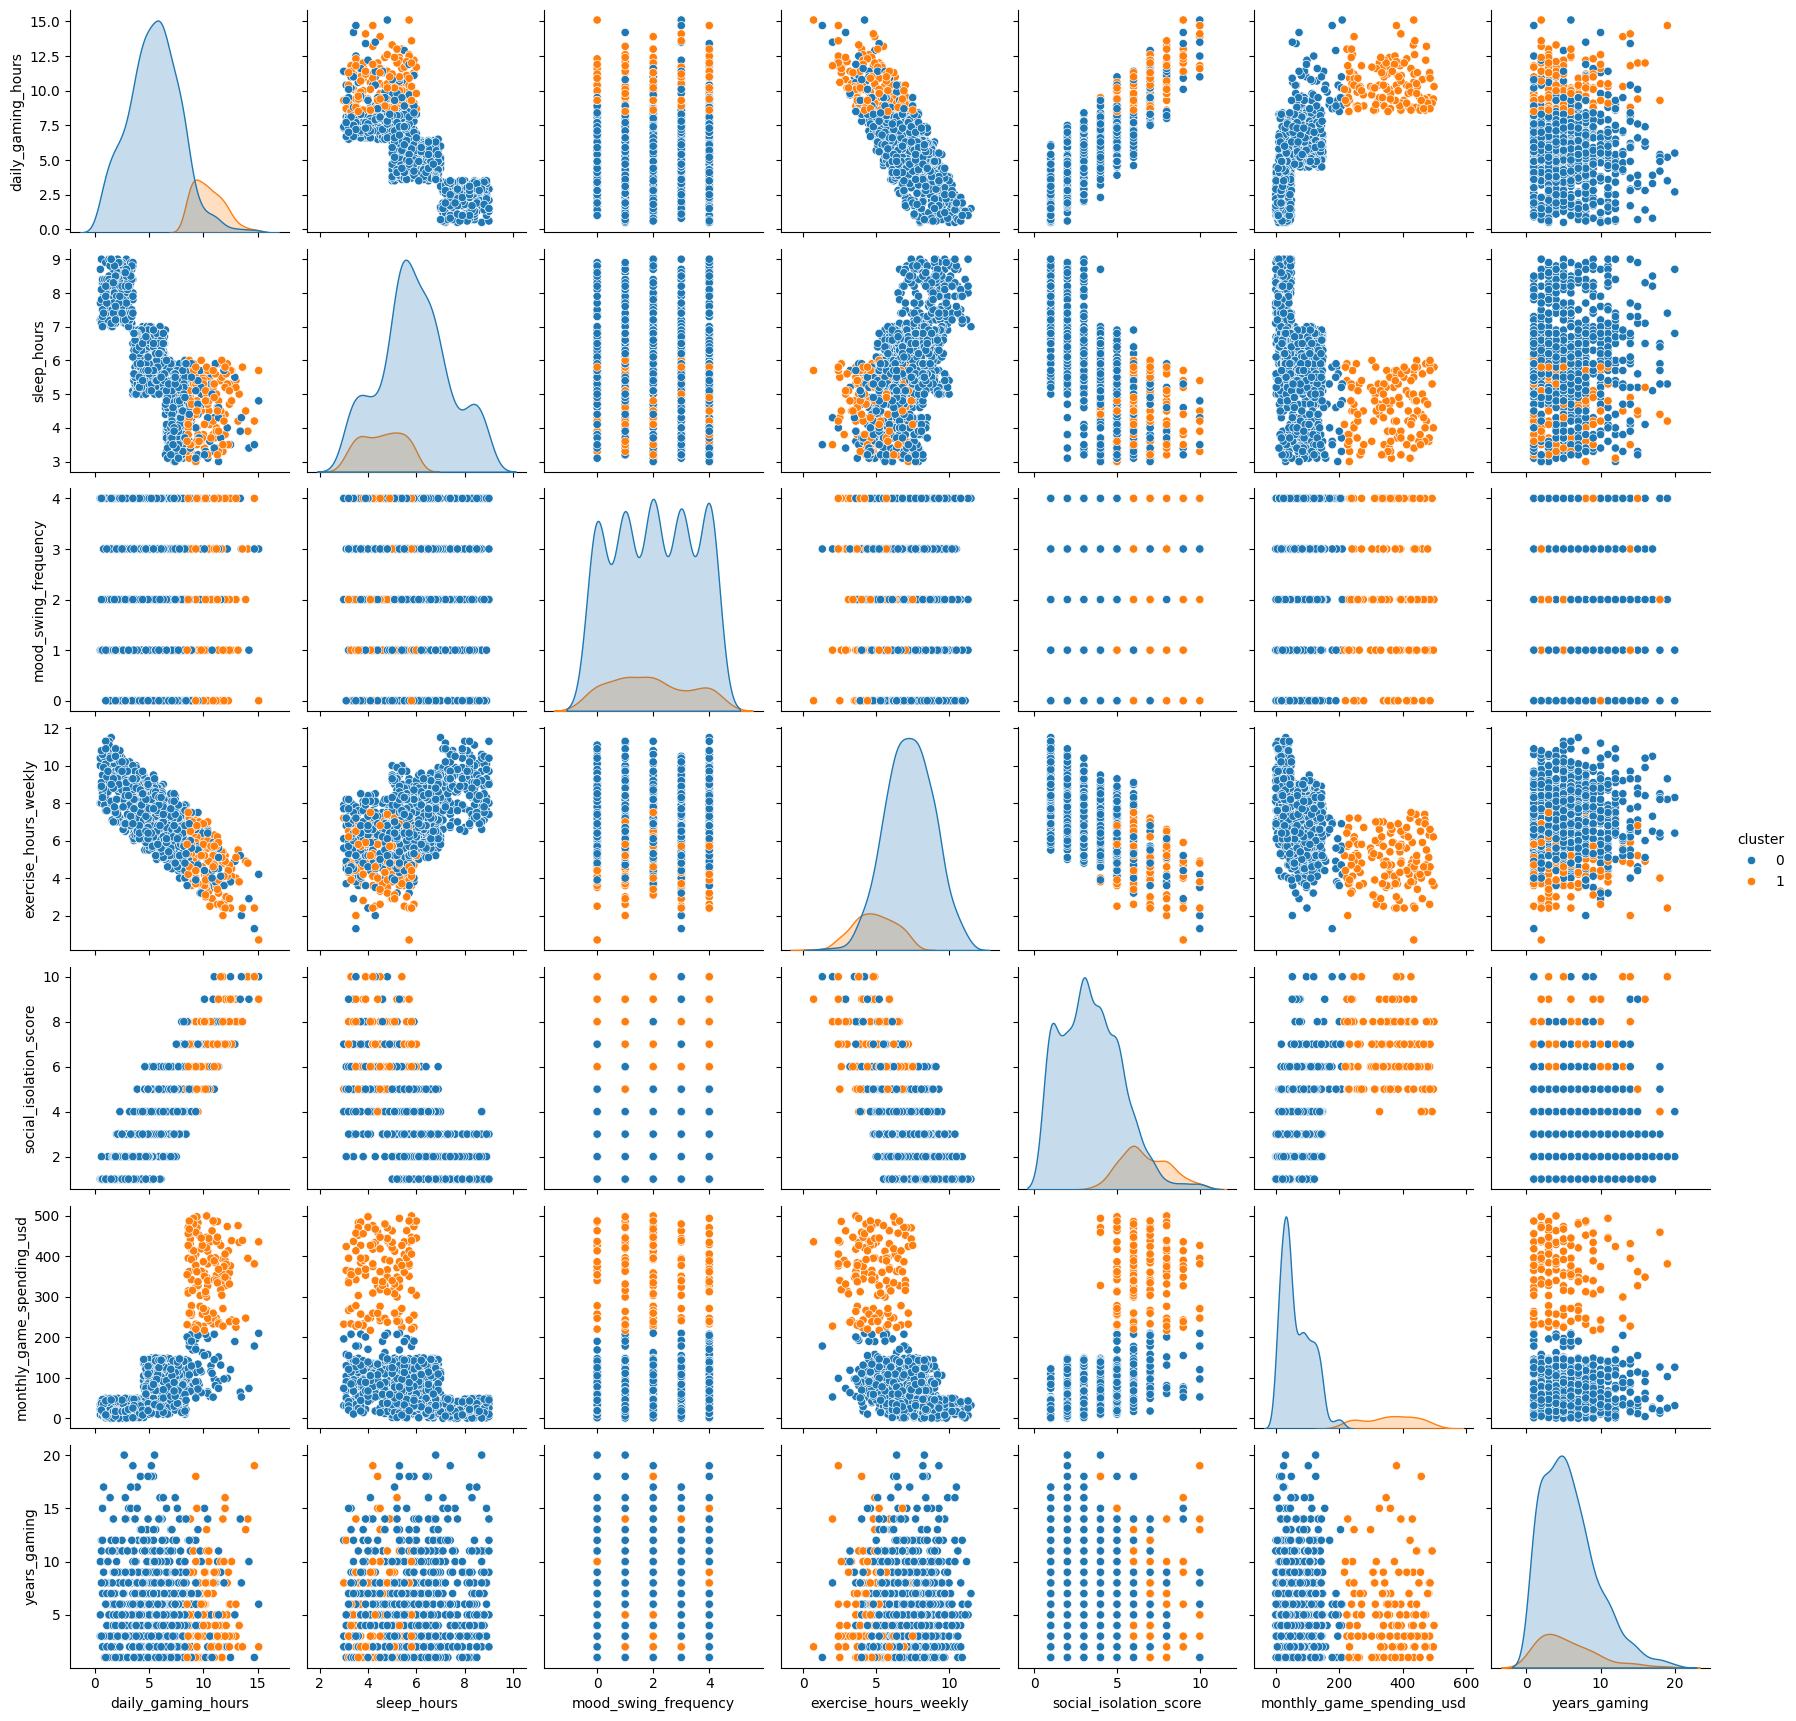

In [31]:
# Add cluster labels as a new column in df_1
df_1['cluster'] = cluster_model_1.labels_
# Now call pairplot with the column name
sns.pairplot(df_1, hue='cluster')

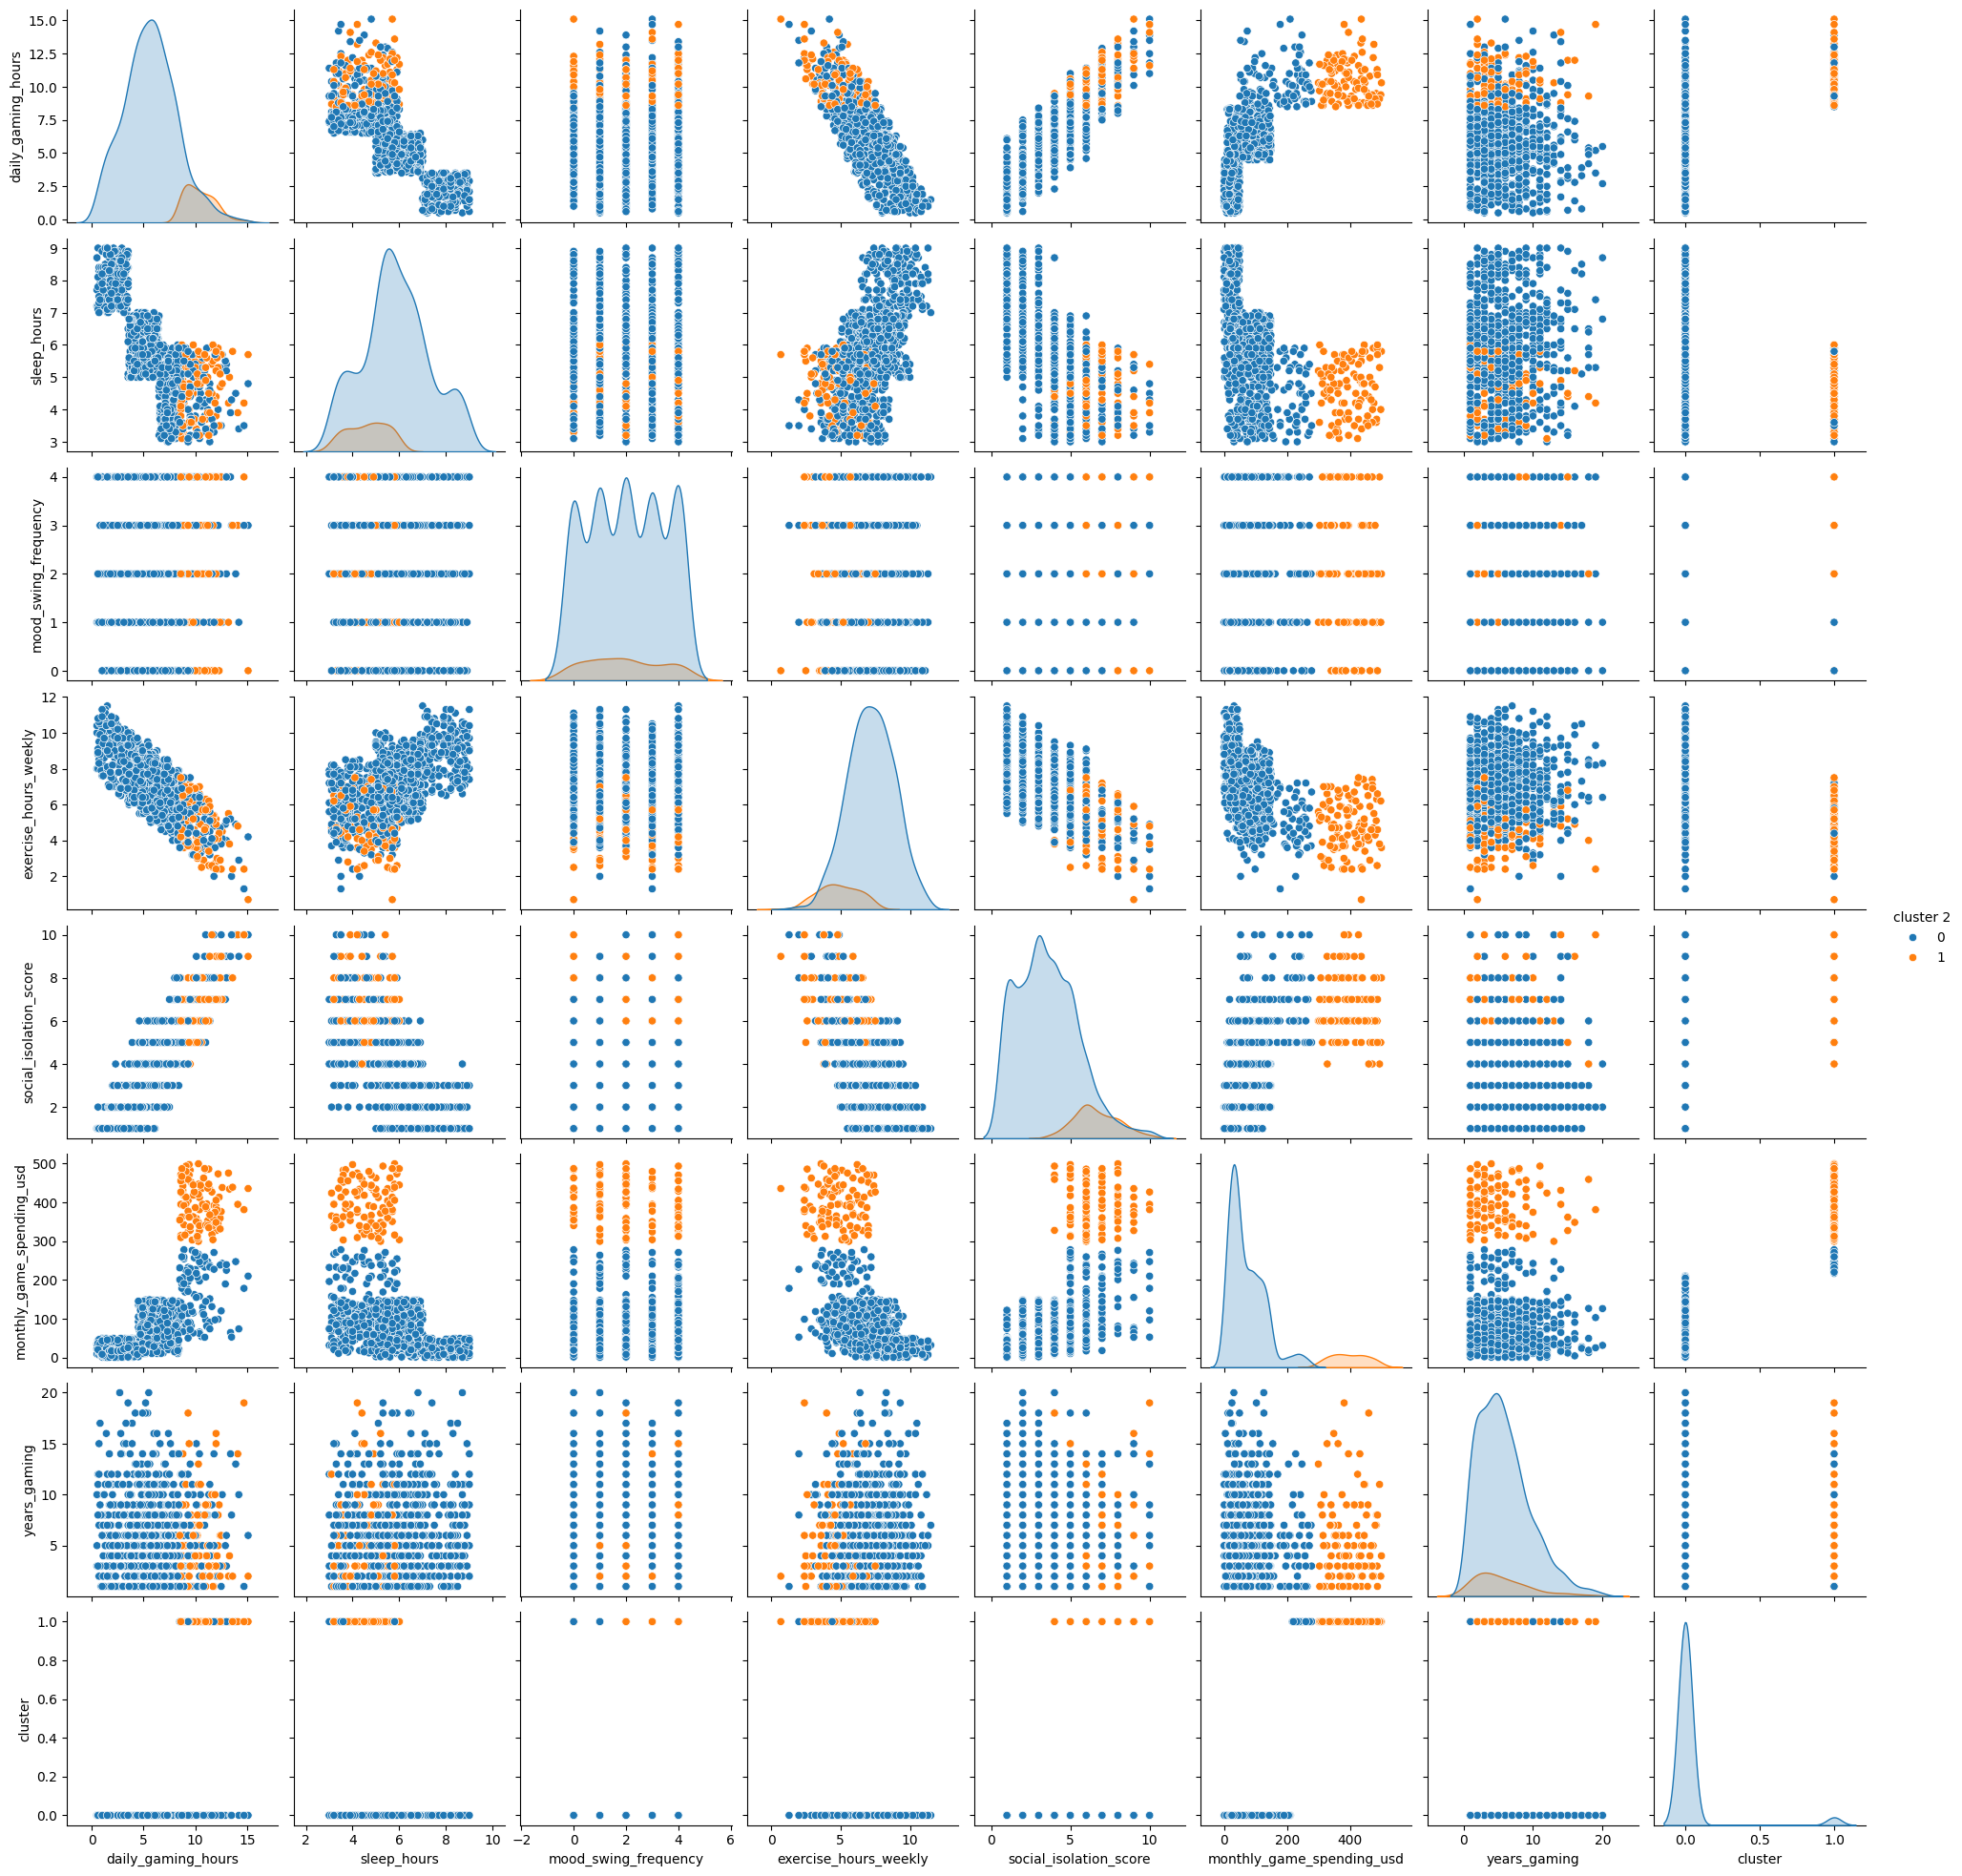

In [32]:
df_1["cluster 2"] = cluster_model_2.labels_
sns.pairplot(df_1, hue='cluster 2')

### step-7 **evaluate the model**

In [26]:
from sklearn.metrics import silhouette_score

print("Silhouette Score for KMeans Clustering : ",silhouette_score(df_1, cluster_model_1.labels_))
print("Silhouette Score for Agglomerative Clustering : ",silhouette_score(df_1, cluster_model_2.labels_))

Silhouette Score for KMeans Clustering :  0.7841336117191049
Silhouette Score for Agglomerative Clustering :  0.7846404067431813


In [27]:
from sklearn.metrics import calinski_harabasz_score

print("Calinski-Harabasz Score for KMeans Clustering : ",calinski_harabasz_score(df_1, cluster_model_1.labels_))
print("Calinski-Harabasz Score for Agglomerative Clustering : ",calinski_harabasz_score(df_1, cluster_model_2.labels_))

Calinski-Harabasz Score for KMeans Clustering :  3689.6756646964704
Calinski-Harabasz Score for Agglomerative Clustering :  3035.1096980381335


In [28]:
from sklearn.metrics import davies_bouldin_score

print("Davies-Bouldin Score for KMeans Clustering : ",davies_bouldin_score(df_1, cluster_model_1.labels_))
print("Davies-Bouldin Score for Agglomerative Clustering : ",davies_bouldin_score(df_1, cluster_model_2.labels_))

Davies-Bouldin Score for KMeans Clustering :  0.37018841122246693
Davies-Bouldin Score for Agglomerative Clustering :  0.28931422108749405


### Hyperparameter-Tuning *(cross validation)*

#### **GridSearchCV**<br>**RandomizedSearchCV**

In [ ]:
"""
hyperparameter tuning for supervised learning models : Linear Regression : fit_intercept, normalize, copy_X, n_jobs
Decision Tree Classifier : criterion, splitter, max_depth, min_samples_split, min_samples_leaf
support vector classifier : kernel, degree, gamma
"""

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

param_grid_lr = {
    'fit_intercept': [True, False],
    'copy_X': [True, False],
    'n_jobs': [-1, 1]
}
param_grid_dt = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': range(1,11),
    'min_samples_split': range(2,11),
    'min_samples_leaf': range(1,11)
}
param_grid_svc = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'degree': range(1,6),
    'gamma': ['scale', 'auto']
}

#performing grid search for hyperparameter tuning
lr_tuning = GridSearchCV(LinearRegression(), param_grid=param_grid_lr, cv=5)
dt_tuning = GridSearchCV(DecisionTreeClassifier(), param_grid=param_grid_dt, cv=5)
svc_tuning = GridSearchCV(SVC(), param_grid=param_grid_svc, cv=5)
#fitting the tuning models
lr_tuning.fit(x_train,y_train)
dt_tuning.fit(x_train,y_train)
svc_tuning.fit(x_train,y_train)
#best hyperparameters for each model
print("Best Hyperparameters for Linear Regression : ",lr_tuning.best_params_)
print("Best Score for Linear Regression : ",lr_tuning.best_score_)
print("Best Hyperparameters for Decision Tree : ",dt_tuning.best_params_)
print("Best Score for Decision Tree : ",dt_tuning.best_score_)
print("Best Hyperparameters for SVM : ",svc_tuning.best_params_)
print("Best Score for SVM : ",svc_tuning.best_score_)

Best Hyperparameters for Linear Regression :  {'copy_X': True, 'fit_intercept': True, 'n_jobs': -1}
Best Score for Linear Regression :  0.6581370639132684
Best Hyperparameters for Decision Tree :  {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 7, 'min_samples_split': 2, 'splitter': 'best'}
Best Score for Decision Tree :  0.7342857142857143
Best Hyperparameters for SVM :  {'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}
Best Score for SVM :  0.6814285714285715


*Now we can use the best hyperparameters to train the final models and evaluate their performance on the test set.*
*The best hyperparameters for each model are obtained from the grid search and can be used to create new instances of the models with*
*those  hyperparameters for final training and evaluation*

In [ ]:
"""
.The best hyperparameters for each model are as follows:
1. Linear Regression: {'copy_X': True, 'fit_intercept': True, 'n_jobs': -1}
2. Decision Tree Classifier: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
3. Support Vector Classifier: {'degree': 1, 'gamma': 'auto', 'kernel': 'poly'}
"""

In [30]:
# Re-training the models with the best hyperparameters
tuned_lr_model = LinearRegression(copy_X=True, fit_intercept=True, n_jobs=-1).fit(x_train,y_train)
tuned_dt_model = DecisionTreeClassifier(criterion='gini',max_depth=5,min_samples_leaf=1,min_samples_split=2,splitter='best').fit(x_train,y_train)
tuned_svc_model = SVC(kernel='poly', degree=1, gamma='auto').fit(x_train,y_train)

In [31]:
# Predicting with the tuned models
tuned_lr_predictions = tuned_lr_model.predict(x_test)
tuned_dt_predictions = tuned_dt_model.predict(x_test)
tuned_svc_predictions = tuned_svc_model.predict(x_test)

In [32]:
#evaluating the performance of the tuned models using appropriate metrics
print("Tuned Linear Regression Performance:")
print("R2 Score : ",r2_score(true_labels,tuned_lr_predictions))
print("Mean Absolute Error : ",mean_absolute_error(true_labels,tuned_lr_predictions))
print("Mean Squared Error : ",mean_squared_error(true_labels,tuned_lr_predictions))
print("----------------------------------------------")
print("Tuned Decision Tree Classifier Performance:")
print("Accuracy Score : ",accuracy_score(true_labels,tuned_dt_predictions))
print("Precision Score : ",precision_score(true_labels,tuned_dt_predictions,average='weighted'))
print("Recall Score : ",recall_score(true_labels,tuned_dt_predictions,average='weighted'))
print("F1 Score : ",f1_score(true_labels,tuned_dt_predictions,average='weighted'))
print("----------------------------------------------")
print("Tuned Support Vector Classifier Performance:")
print("Accuracy Score : ",accuracy_score(true_labels,tuned_svc_predictions))
print("Precision Score : ",precision_score(true_labels,tuned_svc_predictions,average='weighted'))
print("Recall Score : ",recall_score(true_labels,tuned_svc_predictions,average='weighted'))
print("F1 Score : ",f1_score(true_labels,tuned_svc_predictions,average='weighted'))

Tuned Linear Regression Performance:
R2 Score :  0.6692408521151416
Mean Absolute Error :  0.5247901434396403
Mean Squared Error :  0.40929974510093964
----------------------------------------------
Tuned Decision Tree Classifier Performance:
Accuracy Score :  0.69
Precision Score :  0.7341108184398311
Recall Score :  0.69
F1 Score :  0.7039693609513339
----------------------------------------------
Tuned Support Vector Classifier Performance:
Accuracy Score :  0.6766666666666666
Precision Score :  0.6933468579897152
Recall Score :  0.6766666666666666
F1 Score :  0.6821328913128144


In [ ]:
"""
Hyperparameter tuning for unsupervised learning models
In unsupervised learning, we do not have a target variable to evaluate the performance of the model
so we rely on internal evaluation metrics such as silhouette score, calinski-harabasz score, and davies-bouldin score to assess the quality of the clusters formed by the model.
"""

In [33]:
param_grid_kmeans = {
    'init': ['k-means++', 'random'],
    'n_init': [10, 20, 30],
    'max_iter': [300, 500, 1000]
}

param_grid_abg = {
    'n_clusters': range(2,11),
    'linkage': ['ward', 'complete', 'average', 'single'],
}

kmeans_tuning = GridSearchCV(KMeans(random_state=42), param_grid=param_grid_kmeans, cv=5)
abg_tuning = GridSearchCV(AgglomerativeClustering(), scoring='roc_auc', param_grid=param_grid_abg, cv=5)
kmeans_tuning.fit(df_1)
abg_tuning.fit(df_1)

c:\Users\91638\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\91638\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 940, in _score
    scores = scorer(estimator, X_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: _BaseScorer.__call__() missing 1 required positional argument: 'y_true'

  warnings.warn(
c:\Users\91638\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\91638\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\

,estimator,AgglomerativeClustering()
,param_grid,"{'linkage': ['ward', 'complete', ...], 'n_clusters': range(2, 11)}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_clusters,2


In [34]:
print("Best Hyperparameters for KMeans Clustering : ",kmeans_tuning.best_params_)
print("Best score for KMeans Clustering : ",kmeans_tuning.best_score_)
print("Best Hyperparameters for Agglomerative Clustering : ",abg_tuning.best_params_)
print("Best score for Agglomerative Clustering : ",abg_tuning.best_score_)

Best Hyperparameters for KMeans Clustering :  {'init': 'random', 'max_iter': 300, 'n_init': 10}
Best score for KMeans Clustering :  -41187.643918638525
Best Hyperparameters for Agglomerative Clustering :  {'linkage': 'ward', 'n_clusters': 2}
Best score for Agglomerative Clustering :  nan


In [35]:
#Retrain the unsupervised models with the best hyperparameters and evaluate their performance using internal evaluation metrics
tuned_kmeans_model = KMeans(n_clusters=2, init= "random",max_iter=1000,n_init=10,random_state=42).fit(df_1)
tuned_abg_model = AgglomerativeClustering(n_clusters=2, linkage='ward').fit(df_1)

In [36]:
print("silhouette_score for tuned KMeans Clustering : ",silhouette_score(df_1, tuned_kmeans_model.labels_))
print("silhouette_score for tuned Agglomerative Clustering : ",silhouette_score(df_1, tuned_abg_model.labels_))

silhouette_score for tuned KMeans Clustering :  0.7841336117191049
silhouette_score for tuned Agglomerative Clustering :  0.7846404067431813


In [37]:
print("calinski_harabasz_score for tuned KMeans Clustering : ",calinski_harabasz_score(df_1, tuned_kmeans_model.labels_))
print("calinski_harabasz_score for tuned Agglomerative Clustering : ",calinski_harabasz_score(df_1, tuned_abg_model.labels_))

calinski_harabasz_score for tuned KMeans Clustering :  3689.6756646964704
calinski_harabasz_score for tuned Agglomerative Clustering :  3035.1096980381335


In [38]:
print("davies_bouldin_score for tuned KMeans Clustering : ",davies_bouldin_score(df_1, tuned_kmeans_model.labels_))
print("davies_bouldin_score for tuned Agglomerative Clustering : ",davies_bouldin_score(df_1, tuned_abg_model.labels_))

davies_bouldin_score for tuned KMeans Clustering :  0.37018841122246693
davies_bouldin_score for tuned Agglomerative Clustering :  0.28931422108749405


**Project Conclusion**

The goal of this project was to analyze gaming behavior and its relationship with mental health factors using machine learning techniques.

First, exploratory data analysis was performed to understand the patterns in the dataset such as gaming hours, sleep hours, spending on games, and mood swings.

Two types of machine learning approaches were applied:

Supervised learning models to predict the level of gaming addiction risk.

Unsupervised learning models (KMeans and Agglomerative clustering) to group gamers with similar behavior patterns.

The clustering results showed that gamers can be divided into different groups based on their gaming habits. One group tends to have higher gaming hours, higher spending on games, and lower sleep hours, which may indicate a higher risk of gaming addiction. Another group shows lower gaming hours and more balanced lifestyle patterns, representing casual gamers.

The clustering model produced a Silhouette Score of approximately 0.78, indicating that the clusters are well separated and the grouping of users is meaningful.

Overall, this project demonstrates that machine learning can help identify patterns in gaming behavior and provide insights into potential gaming addiction risks. Such analysis can be useful for researchers, psychologists, and policymakers to better understand gaming habits and their possible impact on mental health.
